# GPT-Image-2 on Microsoft Foundry - Part 4: Compose

Keyless (Entra ID) image composition and inpainting with **gpt-image-2** on Azure AI Foundry.

> Reference: https://techcommunity.microsoft.com/blog/azure-ai-foundry-blog/introducing-openais-gpt-image-2-in-microsoft-foundry/4500571

## 1. Settings

In [1]:
import base64
import datetime
import io
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import os
import random
import requests
import sys
import time

from azure.identity import DefaultAzureCredential, get_bearer_token_provider
from contextlib import contextmanager
from dotenv import load_dotenv
from openai import AzureOpenAI
from pathlib import Path
from PIL import Image, ImageDraw

In [2]:
print(f"Python {sys.version}")
print(f"Today is {datetime.datetime.today():%d-%b-%Y %H:%M:%S}")

Python 3.10.19 (main, Oct 21 2025, 16:43:05) [GCC 11.2.0]
Today is 18-May-2026 11:55:08


## 2. Configuration

In [3]:
load_dotenv("azure.env", override=True)

endpoint: str = os.environ["ENDPOINT"]
api_version: str = os.getenv("AZURE_OPENAI_API_VERSION", "2025-04-01-preview")
deployment_name: str = os.getenv("AZURE_OPENAI_DEPLOYMENT_NAME", "gpt-image-2")

EDITS_URL: str = (
    f"{endpoint.rstrip('/')}/openai/deployments/"
    f"{deployment_name}/images/edits?api-version={api_version}"
)

In [4]:
INPUT_DIR  = Path("input")

OUTPUT_DIR = Path("compose")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [5]:
print(f"Deployment : {deployment_name}")
print(f"API version: {api_version}")
print(f"Output dir : {OUTPUT_DIR.resolve()}")

Deployment : gpt-image-2
API version: 2025-04-01-preview
Output dir : /mnt/batch/tasks/shared/LS_root/mounts/clusters/seretkow1/code/Users/seretkow/gptimage2/compose


## 3. Authentication (Entra ID - keyless)

In [6]:
COGNITIVE_SCOPE = "https://cognitiveservices.azure.com/.default"

# One credential object, caches and auto-renews tokens internally
_credential = DefaultAzureCredential()


def get_auth_headers() -> dict[str, str]:
    """Return a fresh Bearer-token Authorization header.

    DefaultAzureCredential.get_token() handles caching and renewal
    internally, so this is safe to call before every API request.

    Returns:
        Dict with a single ``Authorization`` key.
    """
    token = _credential.get_token(COGNITIVE_SCOPE)
    return {"Authorization": f"Bearer {token.token}"}


def _build_openai_client() -> AzureOpenAI:
    """Build an AzureOpenAI client backed by the shared Entra ID credential.

    Returns:
        Configured AzureOpenAI instance.
    """
    token_provider = get_bearer_token_provider(_credential, COGNITIVE_SCOPE)
    return AzureOpenAI(
        azure_endpoint=endpoint,
        azure_ad_token_provider=token_provider,
        api_version=api_version,
    )


# Smoke-test: acquire a token and show its expiry
try:
    tok = _credential.get_token(COGNITIVE_SCOPE)
    print(f"Token acquired. Expires: {datetime.datetime.fromtimestamp(tok.expires_on)}")
except Exception as exc:
    print(f"Auth failed: {exc}\nRun 'az login' or check your managed identity.")

Token acquired. Expires: 2026-05-18 12:08:25


## 4. Helper utilities

In [7]:
@contextmanager
def timer(label: str = ""):
    """Context manager that prints elapsed wall-clock time.

    Args:
        label: Optional description printed before the elapsed time.
    """
    start = time.monotonic()
    yield
    elapsed = time.monotonic() - start
    minutes, seconds = divmod(elapsed, 60)
    tag = f"{label}: " if label else ""
    print(f"⏱️ {tag} image generation. Done in {int(minutes)} minutes and {seconds:.0f} seconds.")


def save_image(b64_data: str, stem: str) -> Path:
    """Decode a base64 PNG string and save it with a timestamp suffix.

    Args:
        b64_data: Base64-encoded PNG string returned by the API.
        stem: Filename stem (without extension or timestamp).

    Returns:
        Path to the saved file.
    """
    ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    path = OUTPUT_DIR / f"{stem}_{ts}.png"
    path.write_bytes(base64.b64decode(b64_data))
    print(f"💾 Saved image: '{path}'")
    return path


def display_images(
    paths: list[str | Path],
    titles: list[str] | None = None,
    fig_width_per_image: float = 5.0,
) -> None:
    """Display one or more images in a single matplotlib row.

    Args:
        paths: Local image file paths.
        titles: Subplot titles (falls back to empty strings).
        fig_width_per_image: Width in inches allocated per image.
    """
    n = len(paths)
    fig, axes = plt.subplots(1, n, figsize=(fig_width_per_image * n, fig_width_per_image))
    
    if n == 1:
        axes = [axes]
    
    for ax, path, title in zip(axes, paths, titles or [""] * n):
        ax.imshow(mpimg.imread(str(path)))
        ax.set_title(title, fontsize=10)
        ax.axis("off")
        
    plt.tight_layout()
    plt.show()


def display_grid_overlay(
    image_path: str | Path,
    grid_size: int = 50,
) -> None:
    """Display an image with a red pixel-coordinate grid for mask planning.

    Args:
        image_path: Path to the source image.
        grid_size: Pixel spacing between grid lines.
    """
    img = Image.open(image_path).convert("RGBA")
    width, height = img.size
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(img)
    
    for x in range(0, width, grid_size):
        ax.axvline(x=x, color="red", linewidth=1.5, alpha=0.8)
    for y in range(0, height, grid_size):
        ax.axhline(y=y, color="red", linewidth=1.5, alpha=0.8)
    
    ax.set_xticks(range(0, width, grid_size))
    ax.set_yticks(range(0, height, grid_size))
    ax.tick_params(axis="both", labelsize=5, colors="red")
    ax.set_title(f"Pixel grid {width}×{height}")
    plt.tight_layout()
    plt.show()
    
    print(f"🖼️ Image size: width = {width}, height = {height}")

In [8]:
def edit_images(
    image_paths: list[str | Path],
    prompt: str,
    mask_path: str | Path | None = None,
    size: str = "1024x1024",
    quality: str = "high",
    n: int = 1,
    max_retries: int = 5,
    backoff_base: float = 2.0,
) -> list[Path]:
    """Call the Azure OpenAI gpt-image-2 edits endpoint with multiple input images.

    Uses Entra ID (DefaultAzureCredential) - no API key required.
    Images are sent via the ``image[]`` multipart field; order matters.
    If a mask is supplied it always applies to ``image[0]``.

    Automatically retries on 429 (rate-limit) and 5xx (transient server)
    errors using exponential backoff with jitter. The ``Retry-After``
    header is respected when present.

    Args:
        image_paths: Local image paths (PNG or JPEG, < 50 MB each, max 16).
        prompt: Text instruction describing the desired edit or composition.
        mask_path: Optional RGBA PNG mask; transparent pixels mark the edit region.
        size: Output resolution — ``1024x1024``, ``1024x1536``, or ``1536x1024``.
        quality: ``low``, ``medium``, or ``high``.
        n: Number of output images to generate (1–10).
        max_retries: Maximum number of retry attempts before raising.
        backoff_base: Base (seconds) for exponential back-off: wait = base^attempt + jitter.

    Returns:
        List of Paths to the saved output images.

    Raises:
        ValueError: If image_paths is empty or exceeds 16 items.
        requests.HTTPError: If all retries are exhausted.
    """
    if not image_paths:
        raise ValueError("At least one image path is required.")
    if len(image_paths) > 16:
        raise ValueError(f"API supports up to 16 images; got {len(image_paths)}.")

    def _build_payload() -> tuple[list[tuple], list[io.BufferedReader]]:
        """Open image files and build the multipart files list.

        Returns:
            Tuple of (files list for requests, open file handles to close later).
        """
        files: list[tuple] = []
        handles: list[io.BufferedReader] = []
        for path in image_paths:
            p = Path(path)
            mime = "image/png" if p.suffix.lower() == ".png" else "image/jpeg"
            fh = open(p, "rb")
            handles.append(fh)
            files.append(("image[]", (p.name, fh, mime)))
            
        if mask_path is not None:
            mp = Path(mask_path)
            fh_mask = open(mp, "rb")
            handles.append(fh_mask)
            files.append(("mask", (mp.name, fh_mask, "image/png")))
        return files, handles

    data = {"prompt": prompt, "size": size, "quality": quality,
            "n": str(n), "output_format": "png"}

    print(f"🧠 Calling Foundry 'gpt-image-2' model [images={len(image_paths)}, size={size}, quality={quality}, n={n}] ...\n")

    RETRYABLE = {429, 500, 502, 503, 504}

    for attempt in range(max_retries + 1):
        files, handles = _build_payload()  # re-open files on every attempt
        try:
            response = requests.post(
                EDITS_URL,
                headers=get_auth_headers(),
                files=files,
                data=data,
            )
        finally:
            for fh in handles:
                fh.close()

        if response.status_code not in RETRYABLE:
            response.raise_for_status()  # surface non-retryable errors immediately
            break

        if attempt == max_retries:
            response.raise_for_status()  # exhausted - let the caller see the error

        # Respect Retry-After header; fall back to exponential backoff + jitter
        retry_after = response.headers.get("Retry-After")
        wait = float(retry_after) if retry_after else backoff_base ** attempt + random.uniform(0, 1)
        print(f"  [{response.status_code}] Rate-limited - retry {attempt + 1}/{max_retries} in {wait:.1f}s...")
        time.sleep(wait)

    result = response.json()

    if usage := result.get("usage"):
        print(f"🔢 Tokens: input = {usage.get('input_tokens')}, "
              f"output = {usage.get('output_tokens')}, "
              f"total = {usage.get('total_tokens')}")

    saved = [save_image(item["b64_json"], f"compose_{i}") for i, item in enumerate(result["data"])]
    print(f"✅ Done: {len(saved)} image(s) generated.")
    return saved

In [9]:
def _pil_to_bytesio(img: Image.Image, fmt: str = "PNG") -> io.BytesIO:
    """Serialize a PIL image to a seeked BytesIO buffer.

    Args:
        img: PIL Image to serialize.
        fmt: PIL format string (default ``PNG``).

    Returns:
        BytesIO positioned at offset 0.
    """
    buf = io.BytesIO()
    img.save(buf, format=fmt)
    buf.seek(0)
    return buf


def create_mask_from_bbox(
    image_size: tuple[int, int],
    bbox: tuple[int, int, int, int],
) -> Image.Image:
    """Create an RGBA inpainting mask from a rectangular bounding box.

    Transparent pixels (alpha=0) define the region to edit;
    opaque pixels (alpha=255) are preserved.

    Args:
        image_size: ``(width, height)`` of the source image.
        bbox: ``(x0, y0, x1, y1)`` pixel coordinates of the edit region.

    Returns:
        RGBA PIL Image usable as an inpainting mask.
    """
    mask = Image.new("RGBA", image_size, (0, 0, 0, 255))  # fully opaque
    ImageDraw.Draw(mask).rectangle(list(bbox), fill=(0, 0, 0, 0))  # transparent edit zone
    return mask


def create_mask_from_polygon(
    image_size: tuple[int, int],
    polygon: list[tuple[int, int]],
) -> Image.Image:
    """Create an RGBA inpainting mask from an arbitrary polygon.

    Useful for non-rectangular edit regions (e.g., around an object).

    Args:
        image_size: ``(width, height)`` of the source image.
        polygon: List of ``(x, y)`` vertices defining the edit region.

    Returns:
        RGBA PIL Image usable as an inpainting mask.
    """
    mask = Image.new("RGBA", image_size, (0, 0, 0, 255))
    ImageDraw.Draw(mask).polygon(polygon, fill=(0, 0, 0, 0))
    return mask


def inpaint(
    image_path: str | Path,
    mask: Image.Image,
    prompt: str,
    output_path: str | Path = "compose/inpainted.png",
    size: str = "1024x1024",
    quality: str = "high",
    n: int = 1,
) -> Path:
    """Perform inpainting with gpt-image-2 using the shared Entra ID credential.

    Resizes the source image and mask to ``size`` if they differ, then
    calls the Azure OpenAI SDK images.edit endpoint.

    Args:
        image_path: Path to the source image.
        mask: RGBA PIL mask (transparent = edit, opaque = preserve).
        prompt: Description of what to generate in the masked region.
        output_path: Where to save the first result image.
        size: Target resolution (``WxH`` string, e.g. ``1024x1024``).
        quality: ``low``, ``medium``, or ``high``.
        n: Number of images to generate.

    Returns:
        Path to the first saved output image.
    """
    target_w, target_h = map(int, size.split("x"))

    source_img = Image.open(image_path).convert("RGBA")
    
    if source_img.size != (target_w, target_h):
        source_img = source_img.resize((target_w, target_h), Image.LANCZOS)
    if mask.size != source_img.size:
        mask = mask.resize(source_img.size, Image.NEAREST)

    client = _build_openai_client()
    
    response = client.images.edit(
        model=deployment_name,
        image=("image.png", _pil_to_bytesio(source_img), "image/png"),
        mask=("mask.png", _pil_to_bytesio(mask), "image/png"),
        prompt=prompt,
        n=n,
        size=size,
        quality=quality,
    )

    output_path = Path(output_path)
    saved_paths: list[Path] = []
    
    for i, item in enumerate(response.data):
        suffix = f"_{i}" if n > 1 else ""
        out = output_path.with_stem(output_path.stem + suffix)
        out.write_bytes(base64.b64decode(item.b64_json))
        print(f"✅ Image saved: '{out}'")
        saved_paths.append(out)

    return saved_paths[0]

## Example 1 - Compositing (2 images)

Place a subject from `image[0]` into the background of `image[1]`.

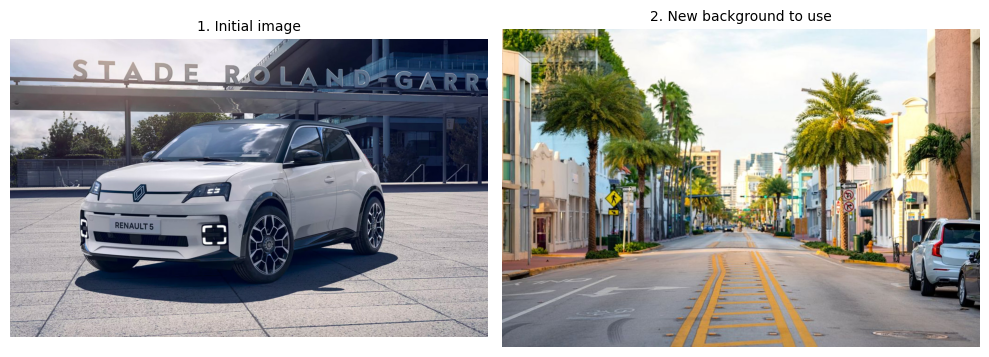

In [20]:
object_file     = INPUT_DIR / "car1.jpg"
background_file = INPUT_DIR / "miami.jpg"

display_images([object_file, background_file], ["1. Initial image", "2. New background to use"])

In [22]:
with timer("Compositing"):
    results_compositing = edit_images(
        image_paths=[object_file, background_file],
        prompt=(
            "Place the subject from the first image into the background of the second image. "
            "Match lighting, perspective, and shadows realistically so the result looks like "
            "a single coherent photograph. Scale the subject as needed. "
            "Change the car color to blue, white and red colors and the licence plate to 'I love Miami'."
        ),
        size="1024x1024",
        quality="high",
    )

🧠 Calling Foundry 'gpt-image-2' model [images=2, size=1024x1024, quality=high, n=1] ...

🔢 Tokens: input = 1684, output = 7024, total = 8708
💾 Saved image: 'compose/compose_0_20260518_124831.png'
✅ Done: 1 image(s) generated.
⏱️ Compositing:  image generation. Done in 4 minutes and 10 seconds


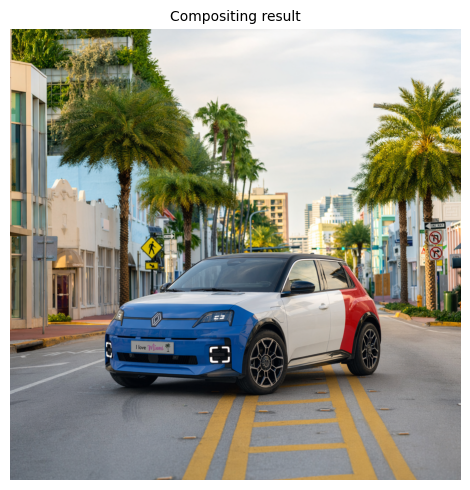

In [23]:
display_images(results_compositing, ["Compositing result"])

## Example 2 - Style transfer (2 images)

Keep the content of `image[0]`, redraw it in the style of `image[1]`.

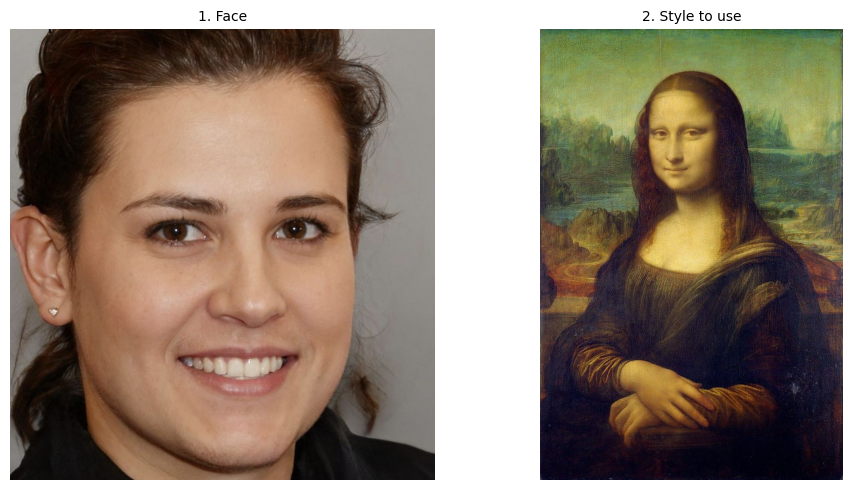

In [24]:
reference_file = INPUT_DIR / "face.jpg"   # Face example from https://this-person-does-not-exist.com
style_file     = INPUT_DIR / "joconde.jpg"

display_images([reference_file, style_file], ["1. Face", "2. Style to use"])

In [25]:
with timer("Style transfer"):
    results_style = edit_images(
        image_paths=[reference_file, style_file],
        prompt=(
            "Redraw the scene from the first image in the artistic style of the second image. "
            "Preserve the composition and subjects exactly. "
            "Apply the colour palette, brushwork, and textures from the style reference."
        ),
        size="1024x1024",
        quality="high",
    )

🧠 Calling Foundry 'gpt-image-2' model [images=2, size=1024x1024, quality=high, n=1] ...

🔢 Tokens: input = 1839, output = 7024, total = 8863
💾 Saved image: 'compose/compose_0_20260518_125251.png'
✅ Done: 1 image(s) generated.
⏱️ Style transfer:  image generation. Done in 3 minutes and 60 seconds


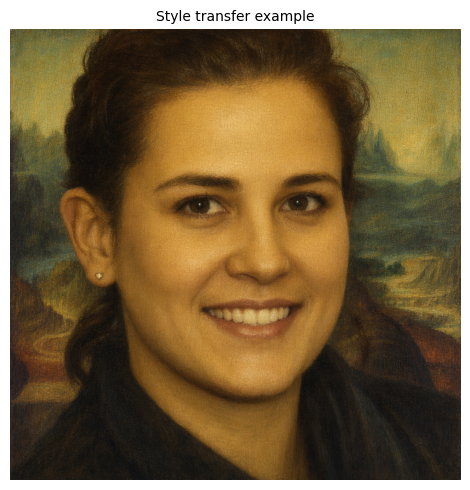

In [26]:
display_images(results_style, ["Style transfer example"])

## Example 3 - Product bundle (3 images)

Compose three individual product shots into one scene.

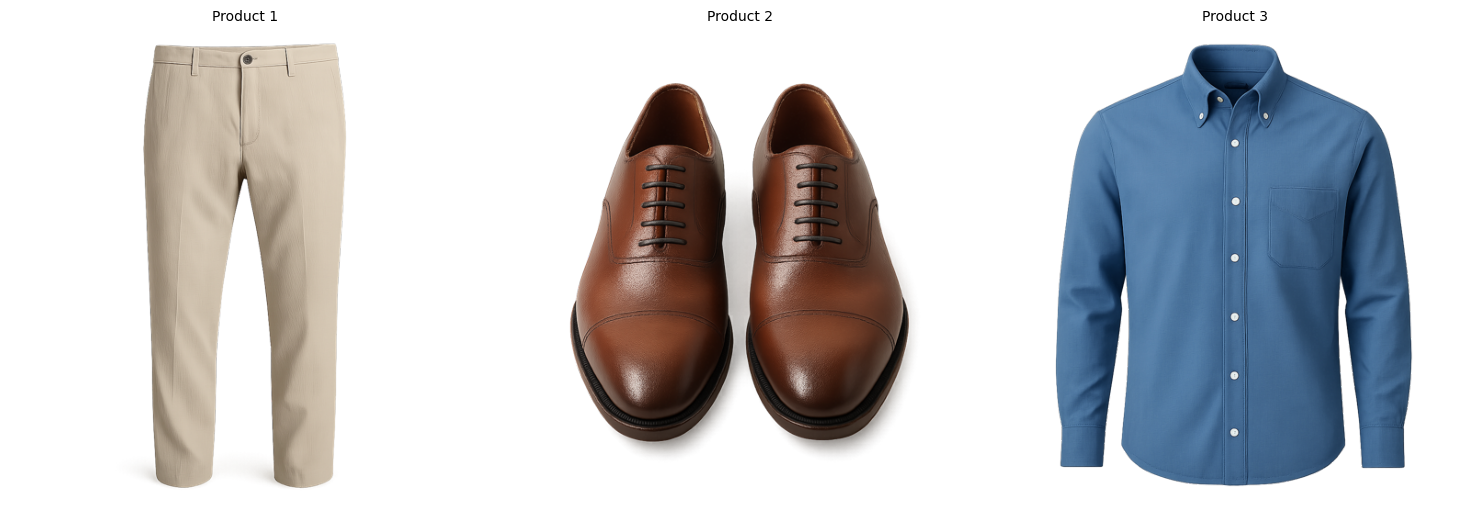

In [27]:
product_files = [INPUT_DIR / f"product{i}.png" for i in range(1, 4)]

display_images(product_files, [f"Product {i+1}" for i in range(len(product_files))])

In [28]:
with timer("Product bundle"):
    results_bundle = edit_images(
        image_paths=product_files,
        prompt=(
            "Arrange all three products on a mannequin in a stylish shop window. "
            "Preserve each product's label and branding exactly as shown. "
            "All three items must be clearly visible. "
            "The shop name is 'Jean Dumartin 2026 collection'."
        ),
        size="1024x1024",
        quality="high",
    )

🧠 Calling Foundry 'gpt-image-2' model [images=3, size=1024x1024, quality=high, n=1] ...

🔢 Tokens: input = 823, output = 7024, total = 7847
💾 Saved image: 'compose/compose_0_20260518_125653.png'
✅ Done: 1 image(s) generated.
⏱️ Product bundle:  image generation. Done in 4 minutes and 1 seconds


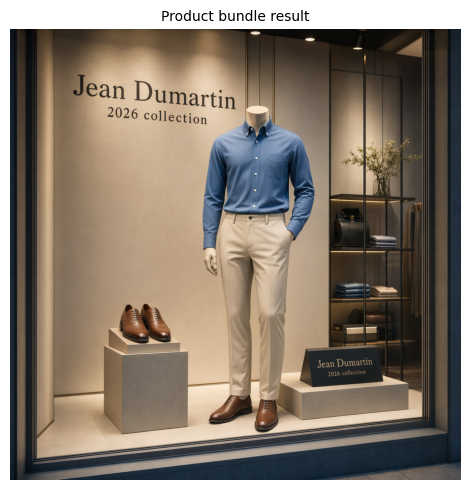

In [29]:
display_images(results_bundle, ["Product bundle result"])

## Example 4 - Character + outfit + scene (3 images)

Dress a character in a specific outfit and place them in a chosen scene.

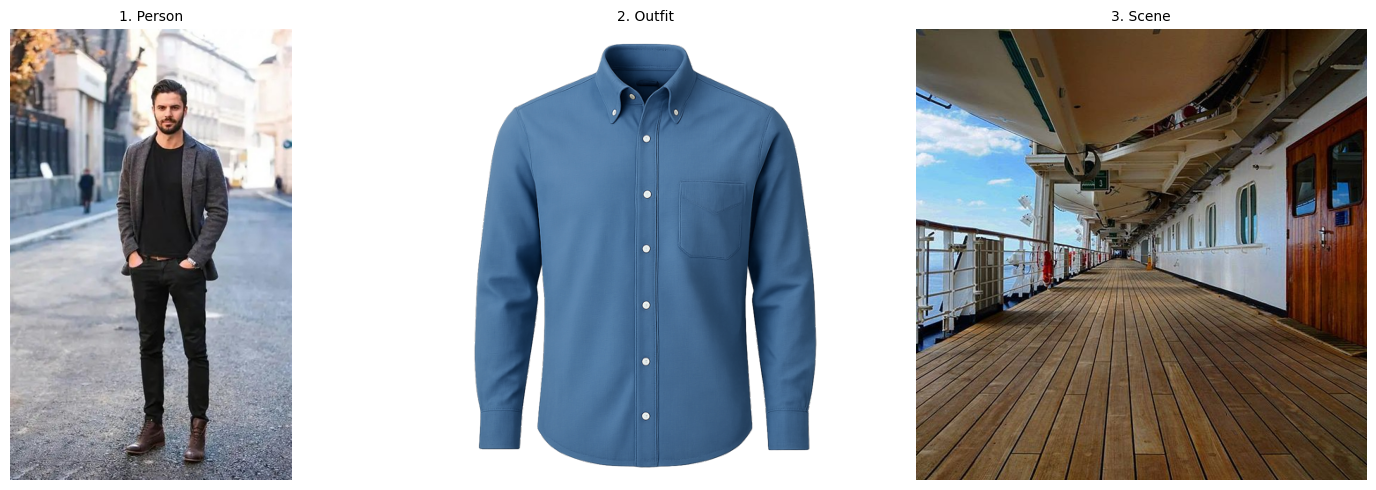

In [30]:
person_file = INPUT_DIR / "man.jpg"
outfit_file = INPUT_DIR / "product3.png"
scene_file  = INPUT_DIR / "deck.jpg"

display_images([person_file, outfit_file, scene_file], ["1. Person", "2. Outfit", "3. Scene"])

In [31]:
with timer("Character + outfit + scene"):
    results_character = edit_images(
        image_paths=[person_file, outfit_file, scene_file],
        prompt=(
            "Place the character from image 1, wearing the outfit from image 2, "
            "into the environment from image 3. "
            "Adapt lighting to match the scene atmosphere."
        ),
        size="1024x1024",
        quality="high",
    )

🧠 Calling Foundry 'gpt-image-2' model [images=3, size=1024x1024, quality=high, n=1] ...

🔢 Tokens: input = 1057, output = 7024, total = 8081
💾 Saved image: 'compose/compose_0_20260518_130059.png'
✅ Done: 1 image(s) generated.
⏱️ Character + outfit + scene:  image generation. Done in 4 minutes and 5 seconds


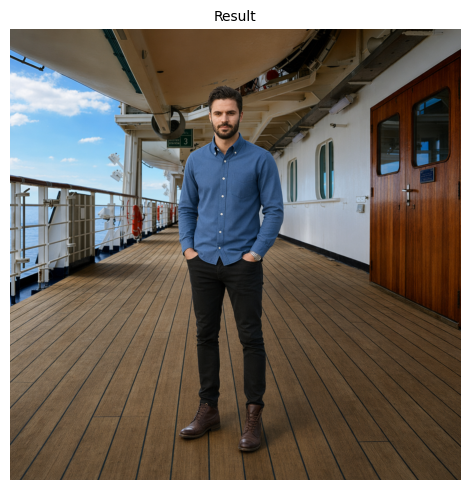

In [32]:
display_images(results_character, ["Result"])

## Example 5 - Inpainting with mask

Replace a specific region of an image using a bounding-box or polygon mask.

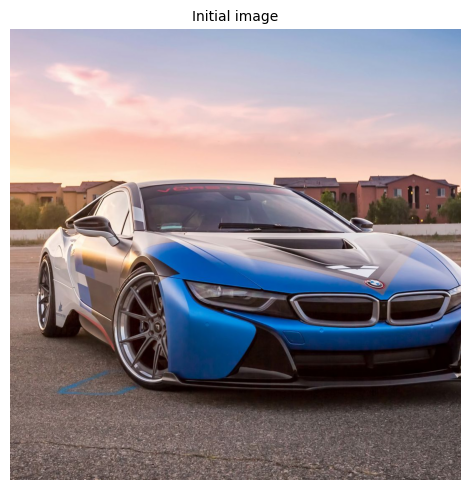

In [33]:
image_file = INPUT_DIR / "car2.jpg"

display_images([image_file], ["Initial image"])

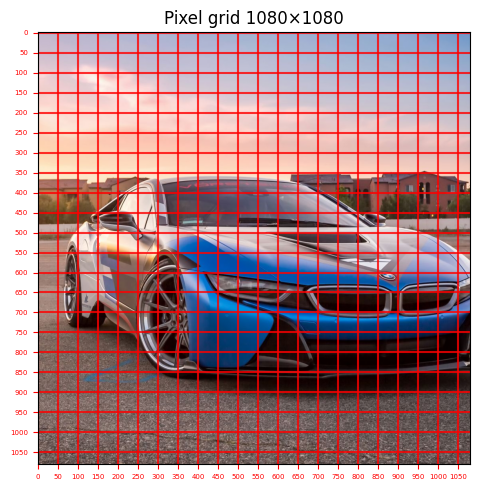

🖼️ Image size: width = 1080, height = 1080


In [34]:
image_file = INPUT_DIR / "car2.jpg"

# Display the image with a pixel grid to plan mask coordinates
display_grid_overlay(image_file, grid_size=50)

In [35]:
source_img = Image.open(image_file).convert("RGBA")

# Option A: rectangular bounding box
mask = create_mask_from_bbox(
    image_size=source_img.size,
    bbox=(0, 0, 1080, 380),  # Mask region
)

# Option B: polygon region example
#mask = create_mask_from_polygon(
#   image_size=source_img.size,
#   polygon=[(200, 100), (600, 80), (650, 400), (180, 420)],
#)

In [36]:
with timer("Inpainting"):
    result_inpaint = inpaint(
        image_path=image_file,
        mask=mask,
        prompt="A sky with light blue color and no clouds, sun on the left part, and some flying birds on the upper right side.",
        output_path=OUTPUT_DIR / "result_inpaint.png",
        size="1024x1024",
        quality="high",
    )

✅ Image saved: 'compose/result_inpaint.png'
⏱️ Inpainting:  image generation. Done in 3 minutes and 48 seconds


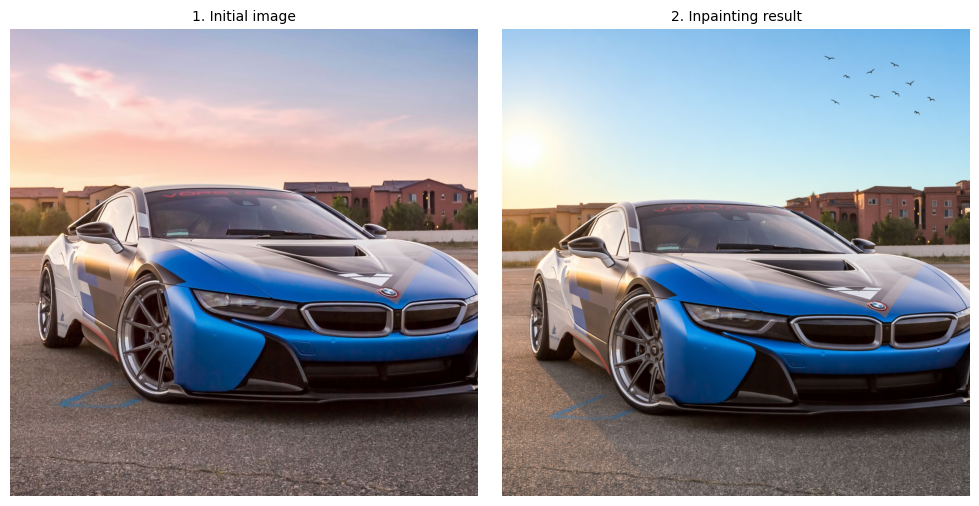

In [37]:
display_images([image_file, result_inpaint], ["1. Initial image", "2. Inpainting result"])

In [38]:
!ls $OUTPUT_DIR -lh

total 12M
-rwxrwxrwx 1 root root 1.7M May 18 11:59 compose_0_20260518_115906.png
-rwxrwxrwx 1 root root 1.7M May 18 12:05 compose_0_20260518_120554.png
-rwxrwxrwx 1 root root 1.7M May 18 12:48 compose_0_20260518_124831.png
-rwxrwxrwx 1 root root 2.0M May 18 12:52 compose_0_20260518_125251.png
-rwxrwxrwx 1 root root 1.5M May 18 12:56 compose_0_20260518_125653.png
-rwxrwxrwx 1 root root 1.7M May 18 13:00 compose_0_20260518_130059.png
-rwxrwxrwx 1 root root 1.5M May 18 13:04 result_inpaint.png
